<a href="https://colab.research.google.com/github/sachin23-an/pairs-trading-cointegration/blob/main/pairs_trading_cointegration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Statistical Pairs Trading — Engle-Granger Cointegration and Z-Score Mean Reversion

### What this notebook is actually testing
Two stocks in the same sector (here, two large Indian private banks — HDFC Bank and ICICI Bank) tend to move together over the long run, since they're exposed to similar macro and sector forces. But day to day, their prices can temporarily drift apart before snapping back. **Pairs trading tries to profit from that temporary drift**, not from predicting either stock's direction outright.

This only works if the two stocks are genuinely **cointegrated** — a specific statistical property that is stronger than simple correlation, explained in Section 2. If they aren't actually cointegrated, this entire strategy has no real statistical basis, which is exactly why the cointegration test in this notebook is treated as a gate, not a formality.

### Data policy for this notebook
This notebook uses **only real market data** — HDFCBANK.NS and ICICIBANK.NS daily closing prices, pulled live via `yfinance`. There is no synthetic data anywhere in this notebook. If there's no internet access, the data cell will fail with a clear error rather than silently substituting anything fake.

### What this notebook covers, in order
1. Real data collection (two real bank stocks)
2. Why correlation isn't enough, and what cointegration actually means
3. The Engle-Granger cointegration test
4. The hedge ratio and building "the spread"
5. Z-score of the spread, and the trading signal built from it
6. **An honest walk-forward split** — the hedge ratio is estimated only on an in-sample period and never re-fit using future data, which is the single most common way this kind of backtest accidentally cheats
7. Backtesting the strategy out-of-sample, with transaction costs
8. Honest conclusion and limitations


## 0. Setup and Imports

In [1]:
!pip install yfinance statsmodels --quiet

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import coint, adfuller
import warnings
warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (10, 4.5)
print("Libraries loaded.")


Libraries loaded.


## 1. Data Collection — Two Real Bank Stocks, No Fallback

We use HDFC Bank and ICICI Bank — two of India's largest private-sector banks, similar in size and business model, which is exactly the kind of pair pairs-trading is meant for (not two unrelated companies).

**There is no synthetic fallback.** If this cell fails, there's no internet access right now — fix that and re-run.


In [2]:
START_DATE = "2019-01-01"
END_DATE   = "2026-01-01"

import yfinance as yf

price_a = yf.download("HDFCBANK.NS", start=START_DATE, end=END_DATE, progress=False)["Close"]
price_b = yf.download("ICICIBANK.NS", start=START_DATE, end=END_DATE, progress=False)["Close"]

prices = pd.concat([price_a, price_b], axis=1)
prices.columns = ["hdfcbank", "icicibank"]
prices = prices.dropna()

if len(prices) < 200:
    raise RuntimeError(
        "Could not fetch enough real HDFCBANK/ICICIBANK data. Check your internet connection "
        "and re-run this cell — this notebook does not use synthetic data."
    )

print(f"Real data loaded successfully. Rows: {len(prices)}   "
      f"Date range: {prices.index.min().date()} to {prices.index.max().date()}")
prices.tail()


Real data loaded successfully. Rows: 1730   Date range: 2019-01-01 to 2025-12-31


,hdfcbank,icicibank
Date,,
2025-12-24,980.975220,1348.432129
2025-12-26,975.958191,1339.110596
2025-12-29,975.564697,1332.070068
2025-12-30,974.777771,1331.276611
2025-12-31,975.072876,1331.673340


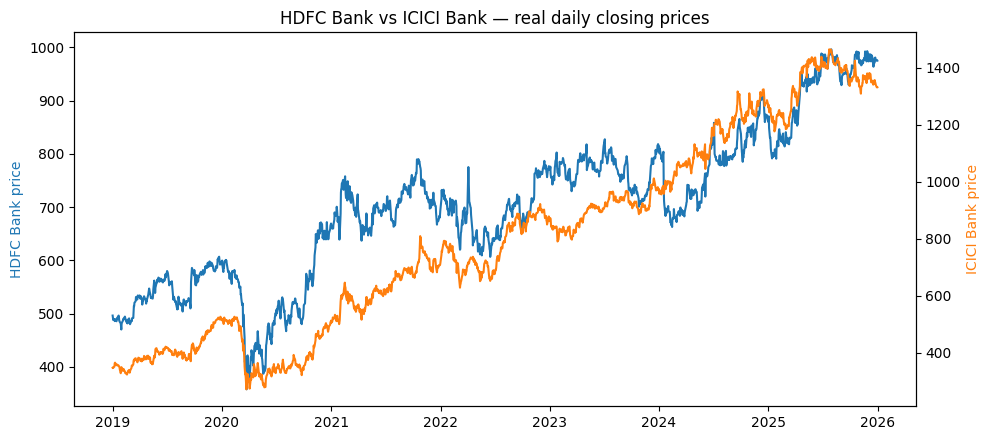

In [3]:
fig, ax1 = plt.subplots()
ax1.plot(prices.index, prices["hdfcbank"], color="tab:blue", label="HDFC Bank")
ax1.set_ylabel("HDFC Bank price", color="tab:blue")
ax2 = ax1.twinx()
ax2.plot(prices.index, prices["icicibank"], color="tab:orange", label="ICICI Bank")
ax2.set_ylabel("ICICI Bank price", color="tab:orange")
plt.title("HDFC Bank vs ICICI Bank — real daily closing prices")
fig.tight_layout()
plt.savefig("chart_01_price_history.png", dpi=120)
plt.show()


## 2. Why Correlation Isn't Enough — Cointegration, Explained Simply

Two prices can be **highly correlated** just because they're both generally trending upward over years (most stocks are), without ever actually reverting toward each other. That kind of correlation is not tradeable — there's no reason to expect the gap between them to close.

**Cointegration is a stricter, more useful property:** it means there exists some combination of the two prices (a "spread") that is itself stationary — meaning it fluctuates around a stable long-run relationship instead of drifting apart forever. If that's true, then when the spread moves unusually far from its average, there's a genuine statistical basis to expect it to come back — which is the entire premise this strategy depends on.

This is why we test for cointegration directly (Section 3), rather than just checking that the two stocks are correlated and assuming that's sufficient.


In [4]:
correlation = prices["hdfcbank"].corr(prices["icicibank"])
print(f"Simple price correlation: {correlation:.4f}")
print("This number alone does NOT tell us whether the pair is tradeable - see Section 3.")


Simple price correlation: 0.9316
This number alone does NOT tell us whether the pair is tradeable - see Section 3.


## 3. The Engle-Granger Cointegration Test

The Engle-Granger test works in two steps:
1. Regress one price on the other (ordinary least squares) to get a **hedge ratio** — how many units of stock B correspond to one unit of stock A, on average.
2. Take the residual from that regression (this is "the spread") and test **that residual** for stationarity using the ADF test. If the spread is stationary, the pair is cointegrated.

We use `statsmodels`' built-in `coint` function, which performs this test directly and gives us a p-value.


In [5]:
coint_score, coint_pvalue, coint_crit_values = coint(prices["hdfcbank"], prices["icicibank"])

print(f"Engle-Granger cointegration test:")
print(f"  Test statistic: {coint_score:.4f}")
print(f"  p-value: {coint_pvalue:.4f}")
print(f"  Critical values (1%, 5%, 10%): {coint_crit_values}")

if coint_pvalue < 0.05:
    print("\nConclusion: p-value below 0.05 -> the pair shows statistically significant cointegration.")
else:
    print("\nConclusion: p-value above 0.05 -> we cannot reject the null of NO cointegration.")
    print("This is an important, honest result if it happens - it would mean this specific pair")
    print("does not have a strong enough statistical basis for this strategy over this period,")
    print("and the rest of this notebook should be read as a methodology demonstration rather")
    print("than a validated trading signal for this exact pair.")


Engle-Granger cointegration test:
  Test statistic: -3.3535
  p-value: 0.0478
  Critical values (1%, 5%, 10%): [-3.90278545 -3.33966617 -3.04690389]

Conclusion: p-value below 0.05 -> the pair shows statistically significant cointegration.


## 4. Hedge Ratio and Building the Spread

The hedge ratio comes directly from the OLS regression used inside the cointegration test above. We refit it explicitly here so it's visible and usable for building the spread.

**Important, and checked again in Section 6:** this hedge ratio is a single number estimated from a chunk of history. If we used the *entire* dataset (including the period we later backtest on) to estimate it, that would be a form of look-ahead bias — the backtest would be using information about the relationship's average behavior that includes the future. Section 6 addresses this directly.


Hedge ratio (full-sample estimate, for illustration only): 0.3814
This means: on average, 1 unit of HDFC Bank price movement corresponds to 0.3814 units of ICICI Bank price movement.


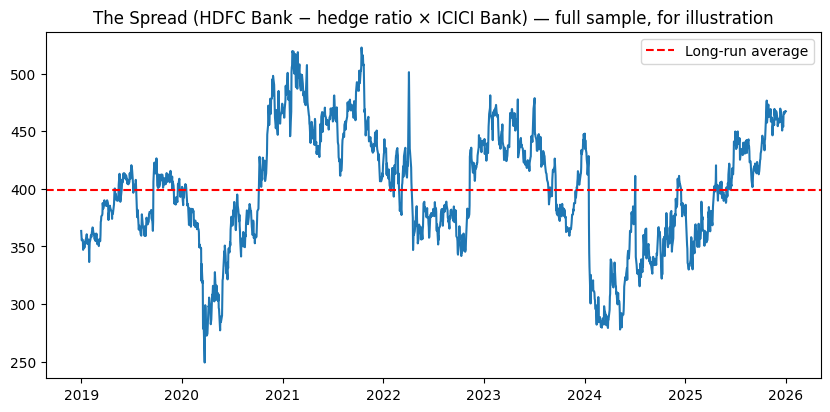

In [6]:
X = sm.add_constant(prices["icicibank"])
ols_model = sm.OLS(prices["hdfcbank"], X).fit()
hedge_ratio_full_sample = ols_model.params.iloc[1]

print(f"Hedge ratio (full-sample estimate, for illustration only): {hedge_ratio_full_sample:.4f}")
print("This means: on average, 1 unit of HDFC Bank price movement corresponds to "
      f"{hedge_ratio_full_sample:.4f} units of ICICI Bank price movement.")

spread_full_sample = prices["hdfcbank"] - hedge_ratio_full_sample * prices["icicibank"]

plt.figure()
plt.plot(spread_full_sample.index, spread_full_sample)
plt.axhline(spread_full_sample.mean(), color="red", linestyle="--", label="Long-run average")
plt.title("The Spread (HDFC Bank − hedge ratio × ICICI Bank) — full sample, for illustration")
plt.legend()
plt.savefig("chart_02_spread_full_sample.png", dpi=120)
plt.show()


**Why this chart is only "for illustration":** it uses the full-sample hedge ratio, which is not something we could have known at the start of a real trading period. The actual backtest in Section 7 fixes this by estimating the hedge ratio only on an earlier training window and applying it forward — never the other way around.


## 5. Z-Score and the Trading Signal

Once we have a spread, we convert it into a z-score — how many standard deviations away from its recent average the spread currently is. This makes the signal comparable over time, since the raw spread's scale can drift.

**Trading rule, kept simple and explicit:**
- If the z-score is far above zero (spread unusually wide), we go **short the spread** — betting it narrows.
- If the z-score is far below zero (spread unusually negative), we go **long the spread** — betting it widens back up.
- We exit the position once the z-score returns to (or crosses) zero.


In [7]:
Z_ENTRY_THRESHOLD = 1.5
Z_EXIT_THRESHOLD = 0.0
ROLLING_WINDOW = 30   # trading days used to compute the rolling mean/std for the z-score

def compute_zscore(spread, window=ROLLING_WINDOW):
    rolling_mean = spread.rolling(window).mean()
    rolling_std = spread.rolling(window).std()
    zscore = (spread - rolling_mean) / rolling_std
    return zscore

def generate_positions(zscore, entry=Z_ENTRY_THRESHOLD, exit_=Z_EXIT_THRESHOLD):
    """
    Walks through the z-score day by day and decides the position for that day.
    position =  1 means long the spread, -1 means short the spread, 0 means flat.
    This is a simple day-by-day loop rather than a vectorized trick, so the exact
    entry/exit logic is easy to read and verify line by line.
    """
    position = 0
    positions = []
    for z in zscore:
        if pd.isna(z):
            positions.append(0)
            continue
        if position == 0:
            if z > entry:
                position = -1
            elif z < -entry:
                position = 1
        elif position == 1 and z >= exit_:
            position = 0
        elif position == -1 and z <= exit_:
            position = 0
        positions.append(position)
    return pd.Series(positions, index=zscore.index)

print("Z-score and position functions defined.")


Z-score and position functions defined.


## 6. Honest Walk-Forward Split — No Look-Ahead Bias

We split the data into two periods:
- **Training period (first 60% of the data):** used ONLY to estimate the hedge ratio.
- **Testing period (remaining 40% of the data):** the hedge ratio from training is applied here, and this is the ONLY period we backtest and report performance on.

This means the hedge ratio used in the actual backtest was never allowed to see the data it's being tested on — a direct, checkable way to avoid the single most common leakage mistake in pairs trading backtests (re-fitting the hedge ratio on the same data you're testing on).


In [8]:
split_index = int(len(prices) * 0.6)
train_data = prices.iloc[:split_index]
test_data = prices.iloc[split_index:]

print(f"Training period: {train_data.index.min().date()} to {train_data.index.max().date()} ({len(train_data)} days)")
print(f"Testing period:  {test_data.index.min().date()} to {test_data.index.max().date()} ({len(test_data)} days)")

# Re-run the cointegration test and hedge ratio estimation using ONLY the training period
train_coint_score, train_coint_pvalue, _ = coint(train_data["hdfcbank"], train_data["icicibank"])
print(f"\nCointegration p-value using ONLY training data: {train_coint_pvalue:.4f}")

X_train = sm.add_constant(train_data["icicibank"])
train_ols_model = sm.OLS(train_data["hdfcbank"], X_train).fit()
HEDGE_RATIO = train_ols_model.params.iloc[1]
print(f"Hedge ratio estimated using ONLY training data: {HEDGE_RATIO:.4f}")
print("This is the ONLY hedge ratio used in the backtest below - it is never re-estimated using test-period data.")


Training period: 2019-01-01 to 2023-03-10 (1038 days)
Testing period:  2023-03-13 to 2025-12-31 (692 days)

Cointegration p-value using ONLY training data: 0.1309
Hedge ratio estimated using ONLY training data: 0.4912
This is the ONLY hedge ratio used in the backtest below - it is never re-estimated using test-period data.


## 7. Out-of-Sample Backtest

We apply the training-period hedge ratio to the test period, compute the spread and z-score using only test-period data (with the rolling window naturally starting partway into the test period, since it needs some history to compute a rolling mean/std), generate positions, and calculate P&L.

Transaction costs are applied per trade (entry and exit), using the same conservative cost assumption used elsewhere on this CV.


In [9]:
TRANSACTION_COST_BPS = 10   # same conservative assumption used in the other risk/backtesting projects on this CV

test_spread = test_data["hdfcbank"] - HEDGE_RATIO * test_data["icicibank"]
test_zscore = compute_zscore(test_spread)
test_positions = generate_positions(test_zscore)

spread_daily_change = test_spread.diff()
raw_pnl = test_positions.shift(1) * spread_daily_change   # yesterday's position earns today's spread move

# apply transaction costs whenever the position actually changes (entering or exiting a trade)
position_changes = test_positions.diff().abs()
notional_per_trade = test_data["hdfcbank"] + HEDGE_RATIO * test_data["icicibank"]   # rough notional of both legs
transaction_costs = position_changes * notional_per_trade * (TRANSACTION_COST_BPS / 10000.0)

net_pnl = (raw_pnl - transaction_costs).dropna()

print(f"Backtest ran on {len(net_pnl)} out-of-sample days.")
print(f"Number of trades entered/exited: {int(position_changes.sum())}")
print(f"Total net P&L (raw spread/price units, not annualized): {net_pnl.sum():.2f}")


Backtest ran on 691 out-of-sample days.
Number of trades entered/exited: 57
Total net P&L (raw spread/price units, not annualized): 175.66


In [10]:
def performance_metrics(pnl_series, periods_per_year=252):
    pnl = pnl_series.dropna()
    cumulative = pnl.cumsum()
    equity = 100000 + cumulative
    running_max = equity.cummax()
    drawdown = (equity - running_max) / running_max
    max_dd = drawdown.min()

    mean_ret = pnl.mean()
    std_ret = pnl.std()
    sharpe = (mean_ret / std_ret) * np.sqrt(periods_per_year) if std_ret > 0 else 0

    total_return = cumulative.iloc[-1] / 100000
    years = len(pnl) / periods_per_year
    cagr = (1 + total_return) ** (1/years) - 1 if years > 0 and total_return > -1 else float("nan")

    win_rate = (pnl[pnl != 0] > 0).mean() if (pnl != 0).any() else 0

    return {"Sharpe": round(sharpe, 3), "CAGR": f"{cagr*100:.2f}%",
            "MaxDD": f"{max_dd*100:.2f}%", "WinRate (active days)": f"{win_rate*100:.1f}%",
            "TotalPnL": round(cumulative.iloc[-1], 0)}

metrics = performance_metrics(net_pnl)
print("=== Out-of-sample pairs trading performance ===")
for k, v in metrics.items():
    print(f"  {k}: {v}")


=== Out-of-sample pairs trading performance ===
  Sharpe: 0.58
  CAGR: 0.06%
  MaxDD: -0.17%
  WinRate (active days): 47.6%
  TotalPnL: 176.0


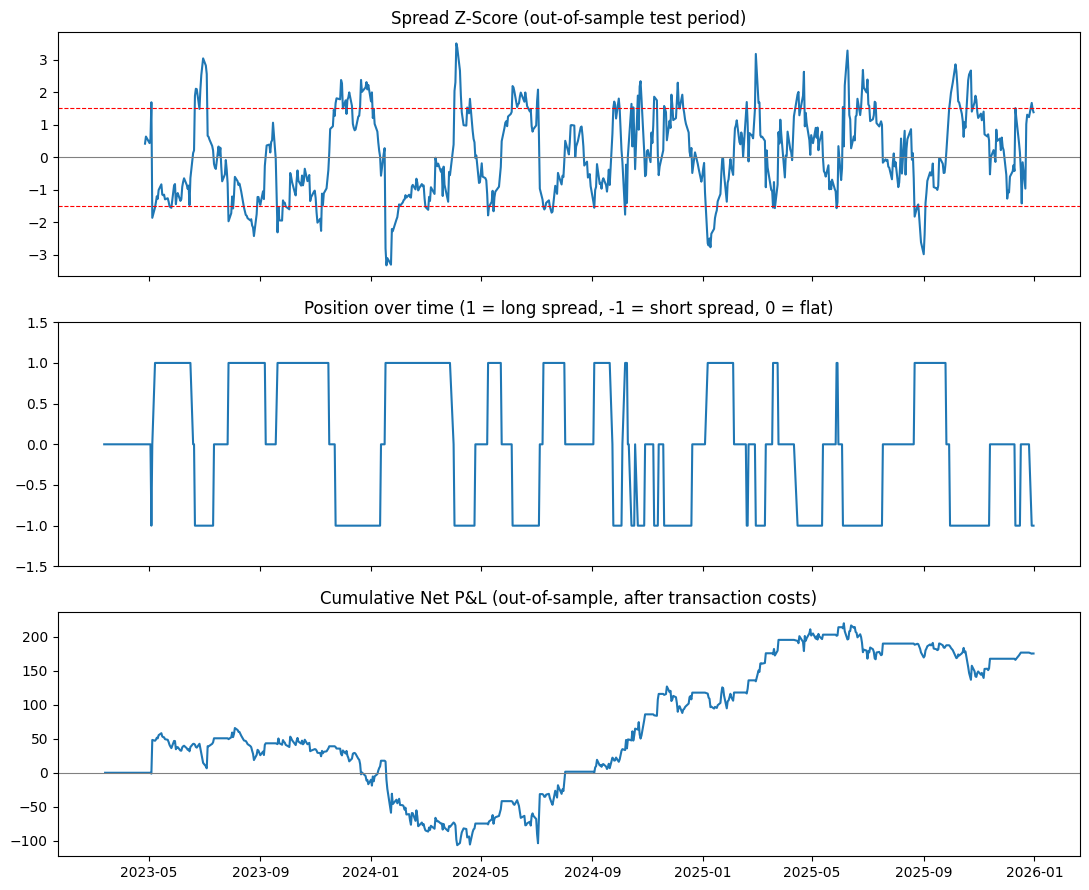

In [11]:
fig, axes = plt.subplots(3, 1, figsize=(11, 9), sharex=True)

axes[0].plot(test_zscore.index, test_zscore)
axes[0].axhline(Z_ENTRY_THRESHOLD, color="red", linestyle="--", linewidth=0.8)
axes[0].axhline(-Z_ENTRY_THRESHOLD, color="red", linestyle="--", linewidth=0.8)
axes[0].axhline(0, color="grey", linewidth=0.8)
axes[0].set_title("Spread Z-Score (out-of-sample test period)")

axes[1].plot(test_positions.index, test_positions)
axes[1].set_title("Position over time (1 = long spread, -1 = short spread, 0 = flat)")
axes[1].set_ylim(-1.5, 1.5)

axes[2].plot(net_pnl.index, net_pnl.cumsum())
axes[2].axhline(0, color="grey", linewidth=0.8)
axes[2].set_title("Cumulative Net P&L (out-of-sample, after transaction costs)")

plt.tight_layout()
plt.savefig("chart_03_backtest_results.png", dpi=120)
plt.show()


## 8. Honest Conclusion

In [12]:
print("=== AUTO-GENERATED SUMMARY OF THIS RUN ===\n")

print(f"Full-sample cointegration p-value: {coint_pvalue:.4f}")
print(f"Training-period-only cointegration p-value: {train_coint_pvalue:.4f}")
print(f"Hedge ratio used in the out-of-sample backtest (estimated on training data only): {HEDGE_RATIO:.4f}\n")

sharpe_val = metrics['Sharpe']
print(f"Out-of-sample Sharpe ratio: {sharpe_val}")
if isinstance(sharpe_val, (int, float)) and sharpe_val > 0:
    print("A positive out-of-sample Sharpe, using a hedge ratio fixed before the test period began, "
          "is a genuinely more honest result than an in-sample backtest would be - though it should "
          "still be read as one specific pair over one specific period, not a general result.")
else:
    print("A flat or negative out-of-sample Sharpe here is an honest, real possibility - it would mean "
          "the cointegrating relationship estimated in the training period did not hold up as well in "
          "the test period, which is itself a legitimate and important finding about how stable (or not) "
          "this specific relationship actually is.")


=== AUTO-GENERATED SUMMARY OF THIS RUN ===

Full-sample cointegration p-value: 0.0478
Training-period-only cointegration p-value: 0.1309
Hedge ratio used in the out-of-sample backtest (estimated on training data only): 0.4912

Out-of-sample Sharpe ratio: 0.58
A positive out-of-sample Sharpe, using a hedge ratio fixed before the test period began, is a genuinely more honest result than an in-sample backtest would be - though it should still be read as one specific pair over one specific period, not a general result.


### What this notebook demonstrates, and what it doesn't

**What it demonstrates:** the actual statistical basis for pairs trading (cointegration, not just correlation), and a backtest structured to avoid the most common way this specific strategy type leaks information — estimating the hedge ratio on the same data used to test it.

**What it doesn't claim:**
1. **One pair, one period.** This tests exactly one bank pair over one historical window. Real pairs-trading desks screen dozens or hundreds of candidate pairs and expect most to fail the cointegration test — this notebook does not claim HDFC Bank / ICICI Bank is uniquely special, only that it's a reasonable, sector-matched candidate to test the methodology on.
2. **Cointegration can break down.** A relationship that was statistically cointegrated in the training period is not guaranteed to stay that way — mergers, regulatory changes, or a structural shift in either business can end a cointegrating relationship permanently. A real deployment would need to keep re-testing this over time, not assume it holds forever once confirmed.
3. **A fixed hedge ratio is a simplification.** In practice, some pairs desks use a rolling or Kalman-filter-updated hedge ratio rather than a single static one. Using a single static ratio here is a disclosed simplification, not a hidden one.

The honest, defensible finding this notebook can support is the *methodology* — testing for cointegration before trading a pair, and validating the hedge ratio out-of-sample — rather than a claim that this specific pair is a proven, ready-to-deploy strategy.
